In [1]:
pip install pandas numpy matplotlib scikit-learn notebook

  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/3f/6b/5610004206cf7f8e7ad91c5a85a8c71b2f2f8051a0c0c4d5916b76d6cbb2/numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata
  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/15.8 MB 220.2 kB/s eta 0:01:12
   ---------------------------------------- 0.0/15.8 MB 219.4 kB/s eta 0:01:12
   ---------------------------------------- 0.1/15.8 MB 403.5 kB/s eta 0:00:39
   ---------------------------------------- 0.2/15.8 MB 696.3 kB/s eta 0:00:23
    --------------------------------------- 0.4/15.8 MB 1.2 MB/s eta 0:00:14
   - -------------------------------------- 0.7/15.

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\RITUL\\anaconda3\\Lib\\site-packages\\~umpy.libs\\libscipy_openblas64_-63c857e738469261263c764a36be9436.dll'
Consider using the `--user` option or check the permissions.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

In [3]:
np.random.seed(0)

data = pd.DataFrame({
    'hour': range(100),
    'usage': np.random.randint(100, 500, 100),
    'day_type': np.random.choice(['Weekday', 'Weekend'], 100)
})

data.head()

,hour,usage,day_type
0,0,272,Weekend
1,1,147,Weekday
2,2,217,Weekend
3,3,292,Weekend
4,4,423,Weekend


In [4]:
# Using only usage for clustering
kmeans = KMeans(n_clusters=3, random_state=0)
data['cluster'] = kmeans.fit_predict(data[['usage']])

data.head()

C:\Users\RITUL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


AttributeError: 'NoneType' object has no attribute 'split'

In [ ]:
plt.figure()
plt.scatter(data['hour'], data['usage'], c=data['cluster'])
plt.title("Usage Clusters")
plt.xlabel("Hour")
plt.ylabel("Energy Usage")
plt.show()

In [5]:
X = data[['hour']]
y = data['usage']

model = LinearRegression()
model.fit(X, y)

future_hours = np.arange(100, 120).reshape(-1, 1)
predictions = model.predict(future_hours)

C:\Users\RITUL\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


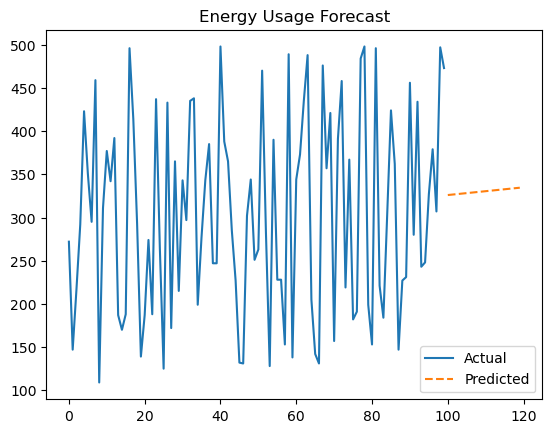

In [6]:
plt.figure()
plt.plot(data['hour'], data['usage'], label='Actual')
plt.plot(future_hours, predictions, label='Predicted', linestyle='dashed')
plt.legend()
plt.title("Energy Usage Forecast")
plt.show()

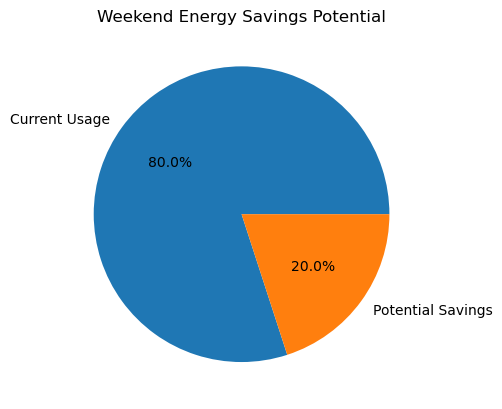

In [7]:
# Assume weekend usage can be reduced by 20%
weekend_usage = data[data['day_type'] == 'Weekend']['usage'].sum()
savings = weekend_usage * 0.2

labels = ['Current Usage', 'Potential Savings']
values = [weekend_usage - savings, savings]

plt.figure()
plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Weekend Energy Savings Potential")
plt.show()